# Splitting videos into a training and a testing set

1. Load annotations from both seasons (2023, 2024)
2. Build a joint data frame containing frame-level annotations
3. Visualize the per-season distribution of every attribute
4. Discard events that contain the single occurence of an attribute in the complete dataset
5. Manually dispatch events containing rare attributes in either the training or the testing set
6. Perform data split at the day level, such that events from the same days are part of the same split. We aim for a train-test ratio of 4:1
7. Visualize attribute distribution per split. We ensure that for every attribute, the proportion of video files in the train set is comprised between 50% and 90% 
8. Visualize the distribution of days per split
9. Add Empty events
10. 

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import calendar
import sqlite3
import os 
from pathlib import Path
import shutil
import json
from tqdm import tqdm

from md_output_parser import MDVideoOutputParser
from events_train_test_split import random_day_split 

%load_ext autoreload
%autoreload 2

In [2]:
# Figure aesthetics
mpl_config = {
    "figure.figsize": (12, 8),
    "figure.dpi": 100,
    "figure.facecolor": "white",

    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "font.size": 15,

    # Title and Label size
    "axes.titlesize": 20,
    "axes.labelsize": 15,

    # Tick parameters
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # Grid and Spines for readability
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.edgecolor": "black",
    "axes.linewidth": 1,

    # Legend
    "legend.fontsize": 12,
    "legend.frameon": True,
    "legend.loc": "best",
}

plt.rcParams.update(mpl_config)

# Steps 1 - 3: Building the joint dataset

### 2024

In [3]:
# Load frame-level annotations in JSON format
annotated_tracklets_folder = Path("/media/EVO870/datasets/SNP_Summer_2024/experiments/Data_Processing_2024/annotated_tracklets_json")
database_path = Path("/media/EVO870/datasets/SNP_Summer_2024/database.db")

md_parser = MDVideoOutputParser()
annotated_tracklets_dict = md_parser.parse_folder(annotated_tracklets_folder)
annotated_tracklets_df = md_parser.to_dataframe()

annotated_tracklets_df.sample(2)

  0%|          | 0/1069 [00:00<?, ?it/s]

100%|██████████| 1069/1069 [00:08<00:00, 130.22it/s]


,frame_id,detections,attributes.Weather,file_id,detection_file_path,max_detection_conf,conf,category,track_id,bbox,...,is_annotated,occluded,segment_id,attributes.Action,attributes.Action2,attributes.Activity,attributes.Social_activity_role,attributes.Deer_adult_sex,attributes.Deer_age,attributes.Species
771051,505,NaN,sunny,S2_C1_E602_V0110,S2/C1/S2_C1_E602_V0110.json,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
642096,1062,NaN,overcast,S1_C2_E21_V0043,S1/C2/S1_C2_E21_V0043.json,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Add metadata about datetime, event id and tublet duration
conn = sqlite3.connect(database_path)
videos_metadata_df = pd.read_sql("SELECT * FROM Videos", con=conn)
tracklets_metadata_df = pd.read_sql("SELECT * FROM Tracklets", con=conn)
trimmed_metatada_df = pd.read_sql("SELECT file_id, trimmed_duration FROM ExperimentData WHERE experiment_name = 'Data_Processing_2024'", con=conn)
conn.close()

annotated_tracklets_df = (
    annotated_tracklets_df[
        ["file_id", "track_id", "segment_id", "frame_id", "is_annotated", "attributes.Action", "attributes.Action2", "attributes.Activity", "attributes.Deer_adult_sex", "attributes.Deer_age", "attributes.Species"]]
    .merge(videos_metadata_df[["file_id", "event_id", "date_time", "site_cam_id", "fps"]], on="file_id")
    .merge(tracklets_metadata_df[["tublet_file_id", "file_id", "track_id", "segment_id", "tublet_duration"]], on=["file_id", "track_id", "segment_id"])
    .merge(trimmed_metatada_df[["file_id", "trimmed_duration"]], on="file_id")
)

# Additional formatting
# Set 2nd action to NaN if "none"
none_action2_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.Action2"] == "none"].index
annotated_tracklets_df.loc[none_action2_idx, "attributes.Action2"] = np.nan

# Lower column names
annotated_tracklets_df.columns = [c.lower() for c in annotated_tracklets_df.columns]

annotated_tracklets_df.sample(2)

,file_id,track_id,segment_id,frame_id,is_annotated,attributes.action,attributes.action2,attributes.activity,attributes.deer_adult_sex,attributes.deer_age,attributes.species,event_id,date_time,site_cam_id,fps,tublet_file_id,tublet_duration,trimmed_duration
407195,S1_C2_E204_V0277,1.0,1.0,19,True,grazing,NaN,foraging,female,adult,red_deer,E204,2024-07-13 00:35:22,S1_C2,30.0,S1_C2_E204_V0277_ID1_T1,8.166667,8.500000
480666,S1_C2_E167_V0219,1.0,1.0,912,True,grazing,NaN,foraging,female,adult,red_deer,E167,2024-07-07 06:58:18,S1_C2,30.0,S1_C2_E167_V0219_ID1_T1,105.700000,120.833333


In [5]:
annotated_tracklets_2024_df = annotated_tracklets_df.copy()

### 2023

In [6]:
# Load frame-level annotations in JSON format
annotated_tracklets_folder = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/SNP_Summer_2023_annotated_tracks_v5")
database_path = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/annotation/raw_videos_metadata.csv")
tracklets_metadata_path = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/annotation/tublets_v5.csv")

md_parser = MDVideoOutputParser()
annotated_tracklets_dict = md_parser.parse_folder(annotated_tracklets_folder)

annotated_tracklets_df = md_parser.to_dataframe()
annotated_tracklets_df.sample(2)

  0%|          | 0/1746 [00:00<?, ?it/s]

100%|██████████| 1746/1746 [00:28<00:00, 61.02it/s] 


,frame_id,max_detection_conf,detections,width,height,attributes.Weather,file_id,detection_file_path,conf,category,...,occluded,segment_id,attributes.Activity,attributes.Action2,attributes.Social_activity_role,attributes.Action,attributes.Species,attributes.Deer_adult_sex,attributes.Deer_age,outside
210130,93,0.975,"{'conf': 0.9750000238418579, 'category': 1, 't...",1920,1080,clear,S1_C2_E122_V0219,S1/C2/S1_C2_E122_V0219.json,0.975,1.0,...,False,1.0,foraging,none,n/a,grazing,red_deer,male,adult,NaN
298516,1392,0.950,"{'conf': 0.949999988079071, 'category': 1, 'tr...",1920,1080,overcast,S1_C2_E146_V0345,S1/C2/S1_C2_E146_V0345.json,0.950,1.0,...,False,1.0,foraging,none,n/a,standing_head_down,red_deer,male,adult,NaN


In [7]:
# Add metadata about datetime, event id and tublet duration
videos_metadata_df = pd.read_csv(database_path)
tracklets_metadata_df = pd.read_csv(tracklets_metadata_path, index_col=0)
tracklets_metadata_df["trimmed_duration_f"] = (tracklets_metadata_df["trimmed_end_frame"] - tracklets_metadata_df["trimmed_start_frame"])

annotated_tracklets_df = (
    annotated_tracklets_df[
        ["file_id", "track_id", "segment_id", "frame_id", "is_annotated", "attributes.Action", "attributes.Action2", "attributes.Activity", "attributes.Deer_age", "attributes.Deer_adult_sex", "attributes.Species"]]
    .merge(videos_metadata_df[["file_id", "event_id", "date_time", "site_id", "cam_id", "fps"]], on="file_id")
    .merge(tracklets_metadata_df[["tublet_file_id", "file_id", "track_id", "segment_id", "tublet_duration", "trimmed_duration_f"]], on=["file_id", "track_id", "segment_id"])
)
annotated_tracklets_df["trimmed_duration"] = annotated_tracklets_df["trimmed_duration_f"] / annotated_tracklets_df["fps"]
annotated_tracklets_df = annotated_tracklets_df.drop("trimmed_duration_f", axis=1)


# Additional formatting
# Set 2nd action to NaN if "none"
none_action2_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.Action2"] == "none"].index
annotated_tracklets_df.loc[none_action2_idx, "attributes.Action2"] = np.nan

# Lower column names
annotated_tracklets_df.columns = [c.lower() for c in annotated_tracklets_df.columns]

# Rename some attributes to match 2024
annotated_tracklets_df = annotated_tracklets_df.rename(columns={"attributes.red_deer_age_group": "attributes.deer_age","attributes.red_deer_adult_sex":"attributes.deer_adult_sex"})
annotated_tracklets_df["attributes.deer_age"] = annotated_tracklets_df["attributes.deer_age"].str.replace("young", "juvenile")
annotated_tracklets_df["attributes.action"] = annotated_tracklets_df["attributes.action"].str.replace("none", "unknown")
annotated_tracklets_df["attributes.activity"] = annotated_tracklets_df["attributes.activity"].str.replace("none", "unknown")

annotated_tracklets_df.sample(2)

,file_id,track_id,segment_id,frame_id,is_annotated,attributes.action,attributes.action2,attributes.activity,attributes.deer_age,attributes.deer_adult_sex,attributes.species,event_id,date_time,site_id,cam_id,fps,tublet_file_id,tublet_duration,trimmed_duration
373732,S1_C1_E68_V0171,1.0,1.0,88,True,grazing,NaN,foraging,adult,male,red_deer,E68,2023-09-04 04:00:22,S1,C1,30.0,S1_C1_E68_V0171_ID1_T1,6.766667,6.666667
314827,S1_C2_E94_V0109,1.0,1.0,5,True,grazing,NaN,foraging,adult,male,red_deer,E94,2023-09-07 22:50:55,S1,C2,30.0,S1_C2_E94_V0109_ID1_T1,20.500000,20.333333


In [8]:
annotated_tracklets_2023_df = annotated_tracklets_df.copy()

### Joining 2024 and 2023

In [9]:
# We rename event_ids of 2024 from EXXX to FXXX, and proceed accordingly for file ids
annotated_tracklets_2024_df["event_id"] = annotated_tracklets_2024_df["event_id"].str.replace("E", "F")
annotated_tracklets_2024_df["file_id"] = annotated_tracklets_2024_df["file_id"].str.replace("E", "F")

# We add a "year" column
annotated_tracklets_2024_df["year"] = 2024
annotated_tracklets_2023_df["year"] = 2023

total_df = pd.concat([annotated_tracklets_2023_df, annotated_tracklets_2024_df], axis=0)

### Visualizing attributes distribution

In [10]:
def get_attribute_df(annotated_tracklets_df: pd.DataFrame, col_name: str):
    if isinstance(col_name, list):
        df = pd.concat([
            annotated_tracklets_df
            .groupby(col)
            .agg({"event_id": pd.Series.nunique, "year": "min"})
            for col in col_name], axis=0)
        attributes_df = df.groupby(level=0).agg({"event_id": "sum", "year": "min"}).sort_values("event_id", ascending=False)
    else:
        attributes_df = (
            annotated_tracklets_df
            .groupby(col_name)
            .agg({"event_id": pd.Series.nunique, "year": "min"})
            .sort_values("event_id", ascending=False)
        )

    attributes_df["perc"] = attributes_df["event_id"] * 100 / attributes_df["event_id"].sum()

    return attributes_df

def plot_multi_season_frequencies(total_df: pd.DataFrame, col_name, log=False):

    df_2023 = total_df[total_df["year"] == 2023]
    df_2024 = total_df[total_df["year"] == 2024]

    total_df = pd.concat([get_attribute_df(df_2023, col_name), get_attribute_df(df_2024, col_name)], axis=0)
    if isinstance(col_name, list):
        total_df = total_df.reset_index(names=col_name[0]).groupby([col_name[0], "year"]).sum().unstack().fillna(0)
    else:
        total_df = total_df.reset_index().groupby([col_name, "year"]).sum().unstack().fillna(0)
    total_df["total"] = total_df[("event_id", 2023)] + total_df[("event_id", 2024)]
    total_df = total_df.sort_values("total", ascending=False)
    total_df["perc"] = total_df["total"] * 100 / total_df["total"].sum()

    fig, ax = plt.subplots(1,1, figsize=(12,8))
    cmap_full = plt.get_cmap("GnBu")
    colors = [cmap_full(i) for i in np.linspace(0.25, 0.8, 2)]
    custom_cmap = ListedColormap(colors)

    total_df[["event_id"]].plot(kind="bar", width=0.8, edgecolor="k", ax=ax, stacked=True, cmap=custom_cmap, logy=log)

    ax.set_xticklabels(total_df.index.to_list(), rotation=30, ha="right")
    plt.grid(axis="y")
        
    # Add percentage text on each bar
    for i, (idx, row) in enumerate(total_df[["total", "perc"]].iterrows()):
        bar = ax.patches[i]
        height = row["total"].values[0] + 2
        perc = "<1" if row["perc"].values[0] < 1.0 else f'{row["perc"].values[0]:.1f}'
        color = "red" if row["total"].values[0] <= 5 else "black"
        ax.text(
            bar.get_x() + bar.get_width()/2, 
            height, 
            f'{row["total"].values[0]:.0f}\n({perc})%', 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            color=color
        )

    ax.set_ylim(0.9, total_df["total"].max() + 40)
    plt.legend(["2023", "2024"])
    
    plt.show()

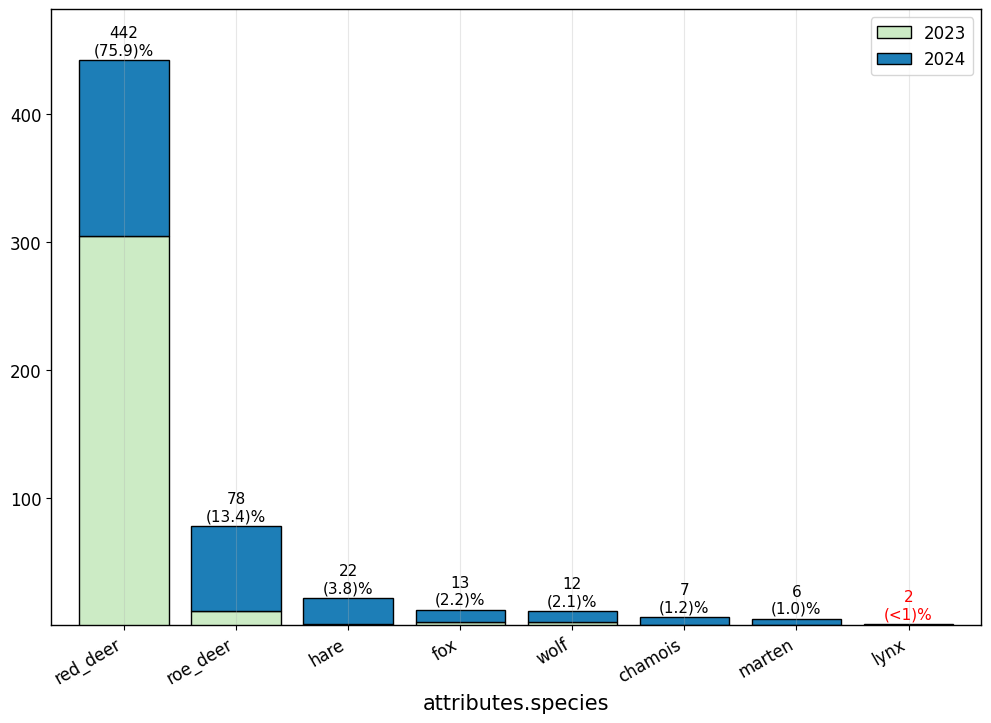

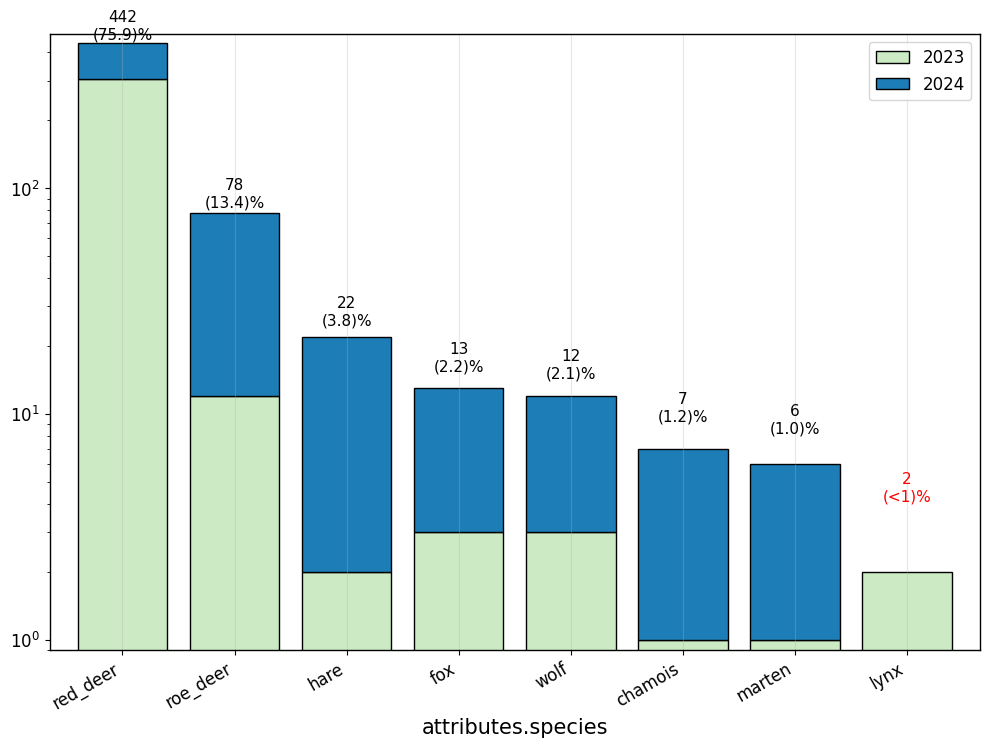

In [11]:
plot_multi_season_frequencies(total_df, "attributes.species")
plot_multi_season_frequencies(total_df, "attributes.species", log=True)

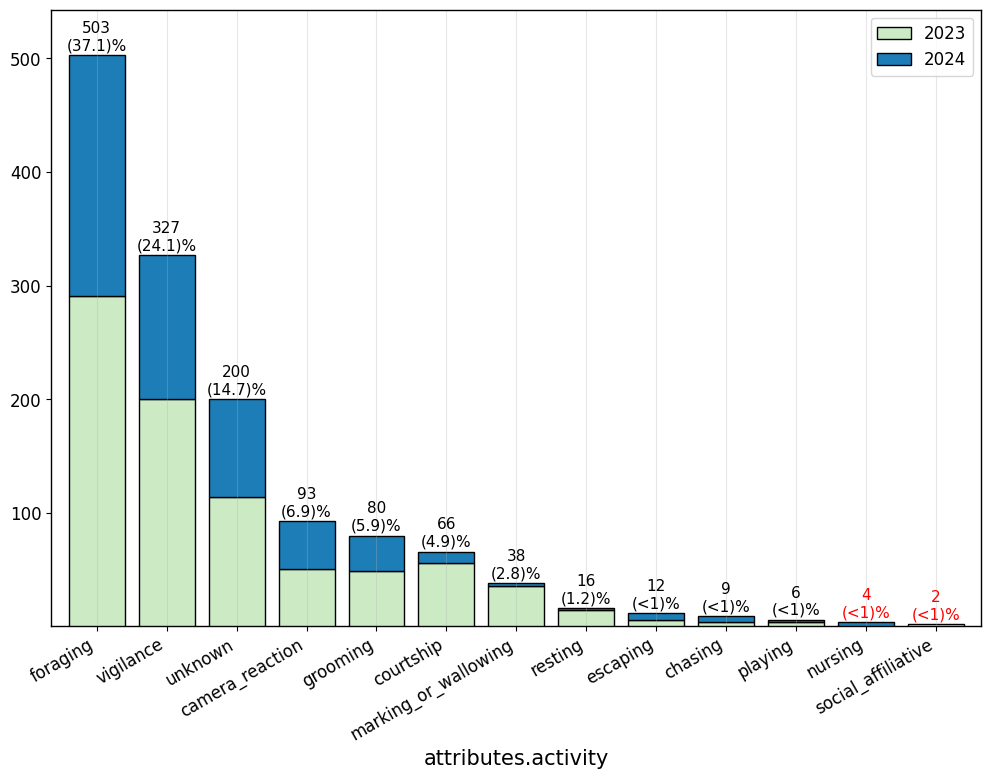

In [12]:
plot_multi_season_frequencies(total_df, "attributes.activity")

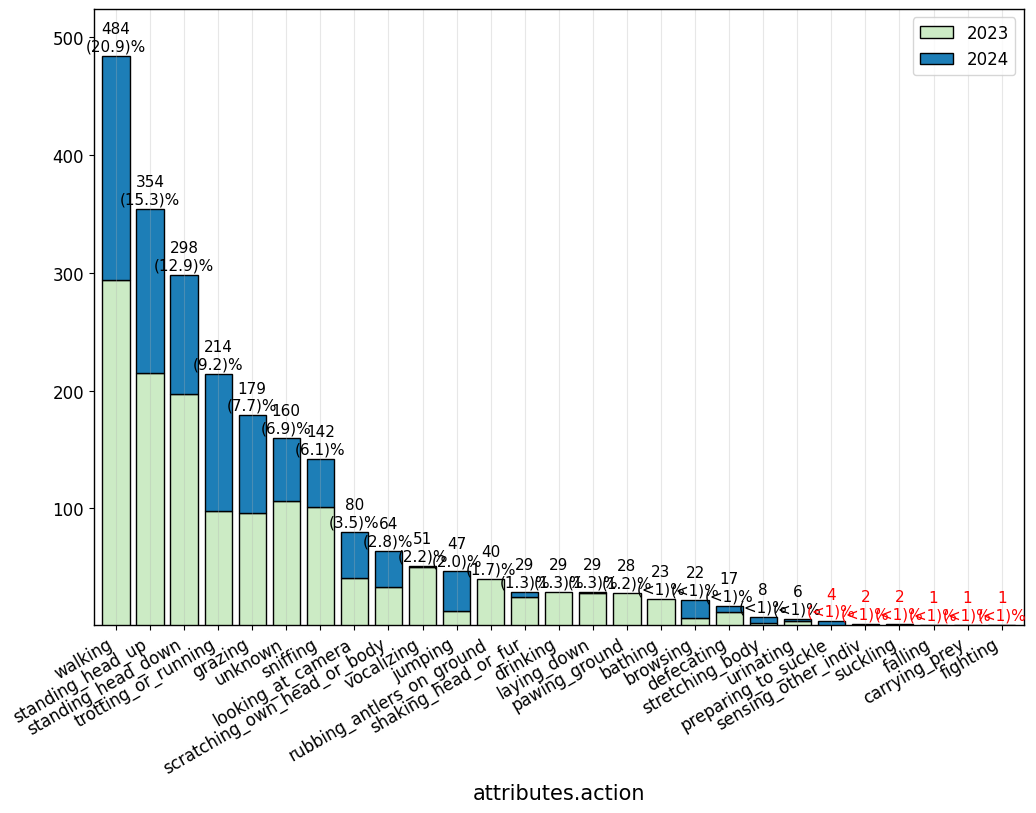

In [13]:
plot_multi_season_frequencies(total_df, ["attributes.action", "attributes.action2"])

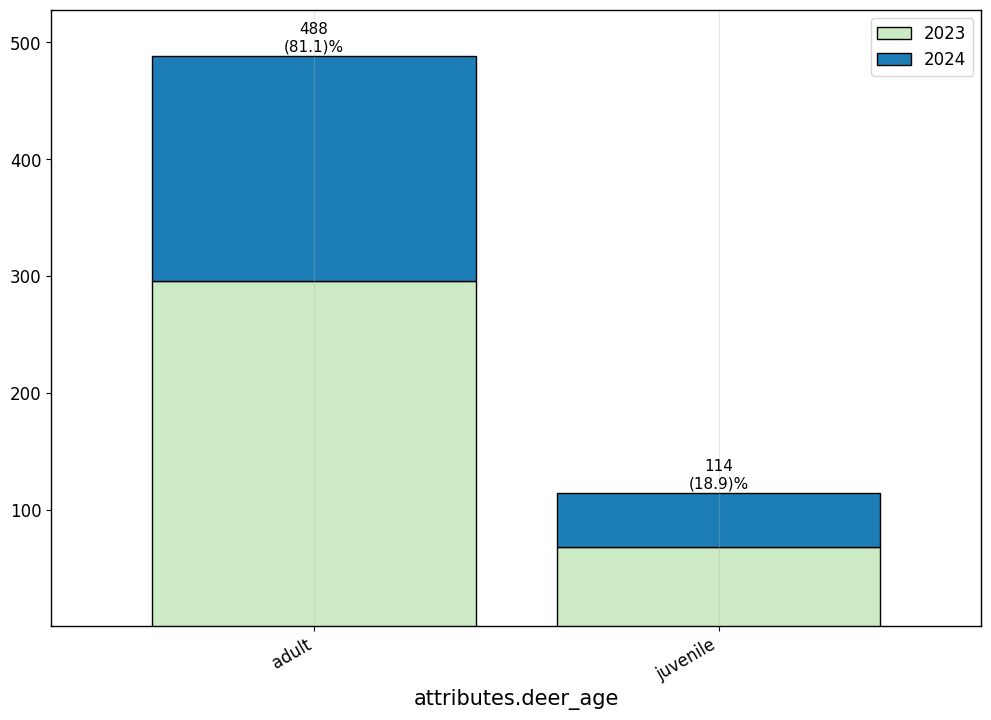

In [14]:
plot_multi_season_frequencies(total_df, "attributes.deer_age")

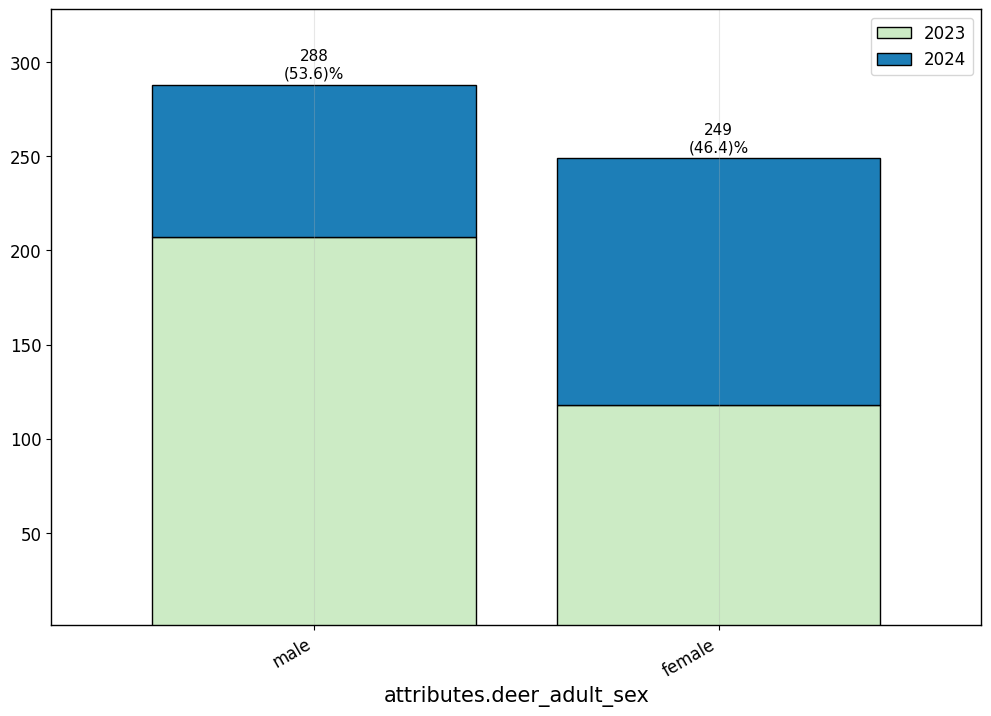

In [15]:
plot_multi_season_frequencies(total_df, "attributes.deer_adult_sex")

# Steps 4 - 8: Making data split and visualizing distributions

In [16]:
DISCARD = [
    "E56",   # Fighting / Social affiliative
    "E99",   # Social affiliative
    "E186",  # Lynx
    "E187",  # Lynx
    "F460",  # Falling
    "F682"   # Carrying_prey
]

MANDATORY_TRAIN= [
    "E51",  # Hare
    "E86",  # Chasing / Escaping
    "E280", # Jumping / Browsing
    "E324", # Fox
    "E327", # Fox
    "E389", # Wolf
    "E394", # Wolf
    "E545", 
    "E642", # Chasing / Escaping
    "E704",
    "E710",
    #"E693", # Playing / Escaping
    #"E766", # Bathing
    #"E769", # Bathing / Urinating
    "F23",  # Chamois
    "F55",  # Chamois
    "F65",  # Chamois
    "F75",  # Playing
    "F230", # Chamois
    "F243", # Streching / Suckling
    "F253", # To add files in train set
    "F386", # Chasing
    "F594", # Fox / Urinating
    "F474", # Marten
    "F475", # Marten
    "F548", # Marten
    "F700", # Defecating
    #"F720",
    "F746", # Defecating
    "F737", # Defecating
    "F863",
]

MANDATORY_TEST = [
    "E61",  # Hare
    "E118", # Defecating
    "E292", # Wolf
    "E385", # Fox
    "E638", # Urinating
    "E671", # Defecating
    "E769", # Bathing / Urinating
    "E351",
    "E693",
    "E766",
    "F163", # Escaping
    "F168", # Chamois
    "F169", # Chamois
    "F269", # To add more juveniles in test set
    "F288", # Event overlapping on 2 days, incl. a test day
    "F404", # Suckling
    "F464", # Fox / Urinating
    "F491", # Marten
    "F498", # Marten
    "F568", # Playing
    "F573", # Wolf / Escaping
    "F604", 
    "F720", # Browsing / Defecating
    #"F863", # Browsing / Defecating
    "F874", # Chasing
]

In [17]:
total_df["split"] = ""

# Checking for potentially overlapping days
split_df = total_df[~total_df["event_id"].isin(DISCARD)].copy().reset_index(drop=True)
split_df["date_time"] = pd.to_datetime(split_df["date_time"])

train_idx = split_df[split_df["event_id"].isin(MANDATORY_TRAIN)].index
test_idx = split_df[split_df["event_id"].isin(MANDATORY_TEST)].index

train_init_dates = split_df[split_df["event_id"].isin(MANDATORY_TRAIN)][
    "date_time"
].dt.date.unique()
test_init_dates = split_df[split_df["event_id"].isin(MANDATORY_TEST)][
    "date_time"
].dt.date.unique()
overlapping_days = set(train_init_dates).intersection(set(test_init_dates))

print("Overlapping days:", set(train_init_dates).intersection(set(test_init_dates)))

Overlapping days: set()


In [18]:
# Perform split
train_events, val_events, test_events = random_day_split(
    annotations_df=split_df,
    train_size=0.70,
    test_size=0.30,
    train_init = MANDATORY_TRAIN, 
    test_init=MANDATORY_TEST, 
    seed=0, 
    n_iter=50,
    no_val=True
)

Search parameters:
	 Target train size: 0.7 - Target val size: 0 - Target test size: 0.3
	 Init train set prop: 0.279
	 Init test set prop: 0.284
	 Number of iterations: 50


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:56<00:00,  1.13s/it]

Train prop: 0.6780698150357374
Val prop: 0.0
Test prop: 0.3219301849642626


In [19]:
split_df.loc[split_df[split_df["event_id"].isin(train_events)].index, "split"] = "train"
split_df.loc[split_df[split_df["event_id"].isin(test_events)].index, "split"] = "test"
print("Entries not assigned to a split:", len(split_df[~split_df["split"].isin(["train", "test"])]))

Entries not assigned to a split: 0


In [38]:
def plot_split_frequencies(df: pd.DataFrame, col_name: str, log=False):

    fig, ax = plt.subplots(1,1, figsize=(12,8))

    # First get total number of events
    if isinstance(col_name, list):
        attributes_df = pd.concat([
            df
            .groupby([col, "split"], as_index=True)
            .agg({"file_id": pd.Series.nunique})
            for col in col_name], axis=0)
        attributes_df = attributes_df.reset_index(names=["attributes", "split"]).groupby(["attributes", "split"]).sum().sort_values("file_id", ascending=False)
    else:
        attributes_df = (
            df
            .groupby([col_name, "split"])
            .agg({"file_id": pd.Series.nunique})
            .sort_values("file_id", ascending=False)
        )
    
    attributes_df = attributes_df.rename(columns={"file_id": "nb_files"})
    total_df = attributes_df.unstack().fillna(0)
    total_df["total"] = total_df[("nb_files", "train")] + total_df[("nb_files", "test")]
    total_df = total_df.sort_values("total", ascending=False)
    total_df["train_split_perc"] = total_df[("nb_files", "train")] * 100 / total_df["total"]
    total_df = total_df.sort_index(level=1, axis=1, ascending=False)

    #cmap_full = plt.get_cmap("OrRd")
    #colors = [cmap_full(i) for i in np.linspace(0.25, 0.8, 2)]
    colors = ["xkcd:sea blue", "xkcd:light yellow"]
    custom_cmap = ListedColormap(colors)

    total_df[["nb_files"]].plot(kind="bar", width=0.8, edgecolor="k", ax=ax, stacked=True, cmap=custom_cmap, logy=log)
    
    ax.set_xticklabels(total_df.index.to_list(), rotation=30, ha="right")
    #plt.grid(axis="y")
        
    # Add percentage text on each bar
    for i, (idx, row) in enumerate(total_df[["total", "train_split_perc"]].iterrows()):
        bar = ax.patches[i]
        height = row["total"].values[0] + 2
        perc = f'{row["train_split_perc"].values[0]:.1f}'
        color = "black"
        ax.text(
            bar.get_x() + bar.get_width()/2, 
            height, 
            f'{perc}%', 
            ha='center', 
            va='bottom', 
            fontsize=9, 
            color=color
        )

    ax.set_ylim(0.9, total_df["total"].max() + 40)
    plt.legend(["train", "test"])
    plt.tight_layout()
    fig.savefig(str(col_name)+".svg", transparent=True)
    plt.show()

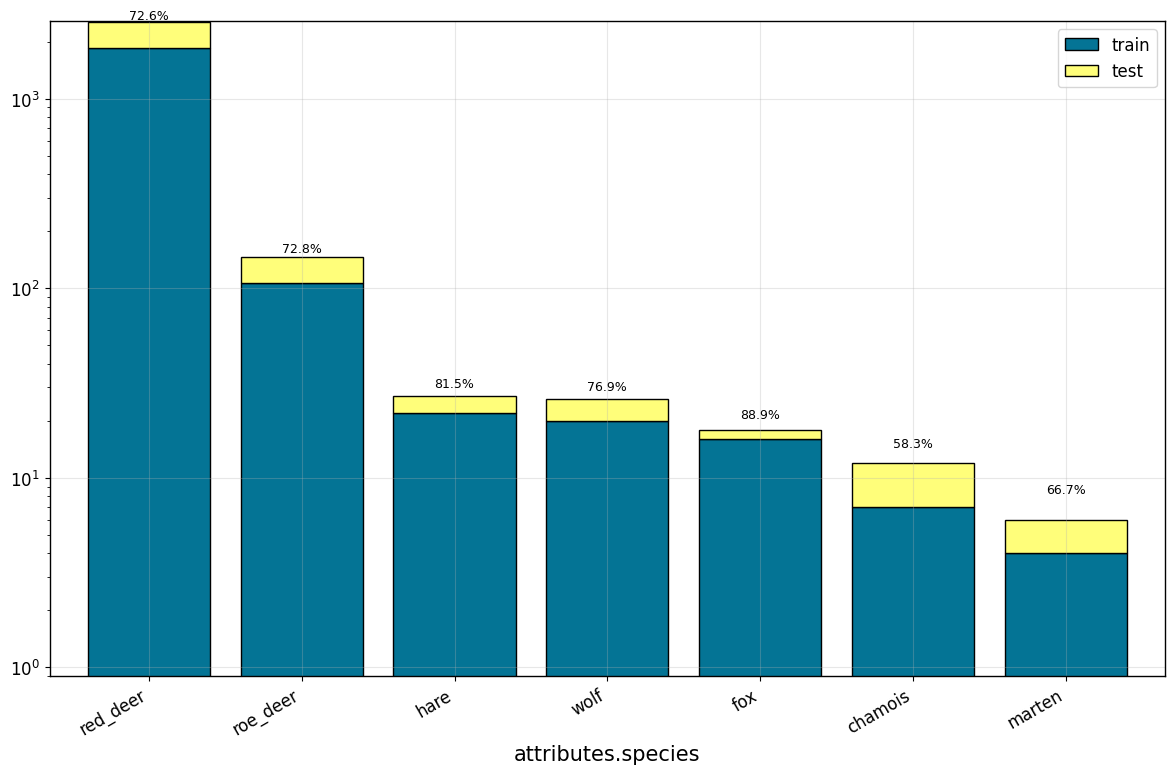

In [39]:
plot_split_frequencies(split_df, "attributes.species", log=True)

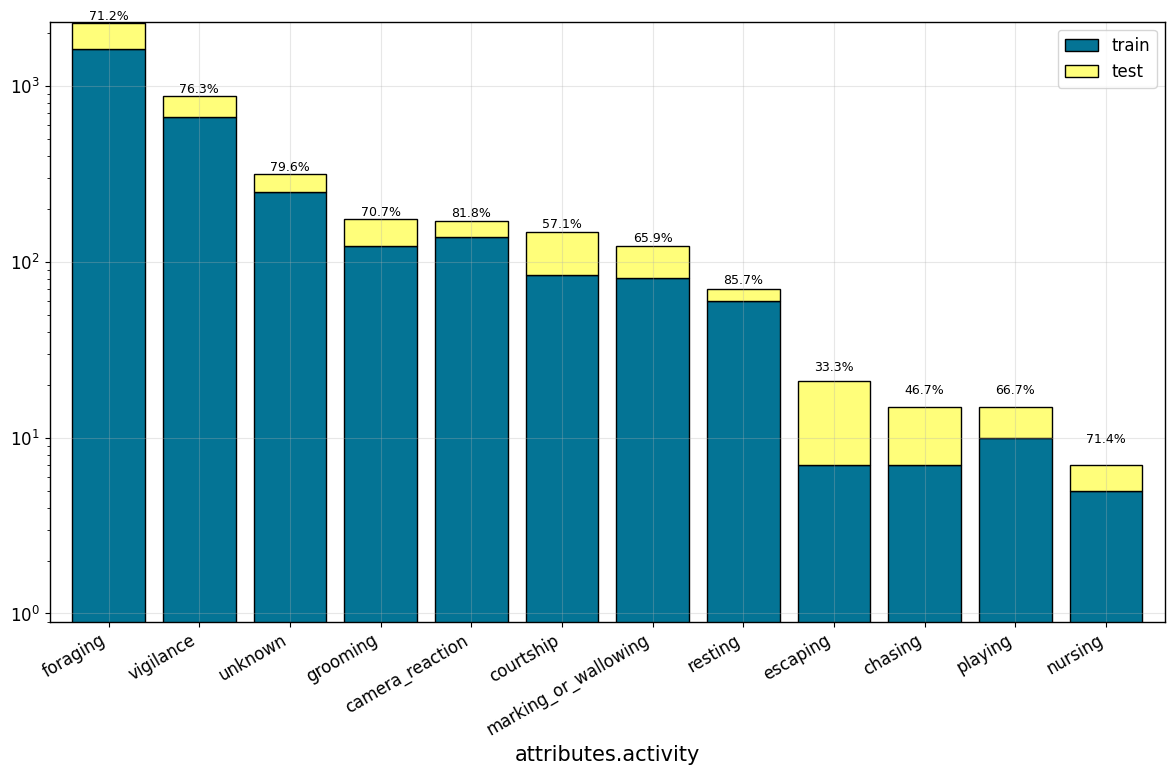

In [40]:
plot_split_frequencies(split_df, "attributes.activity", log=True)

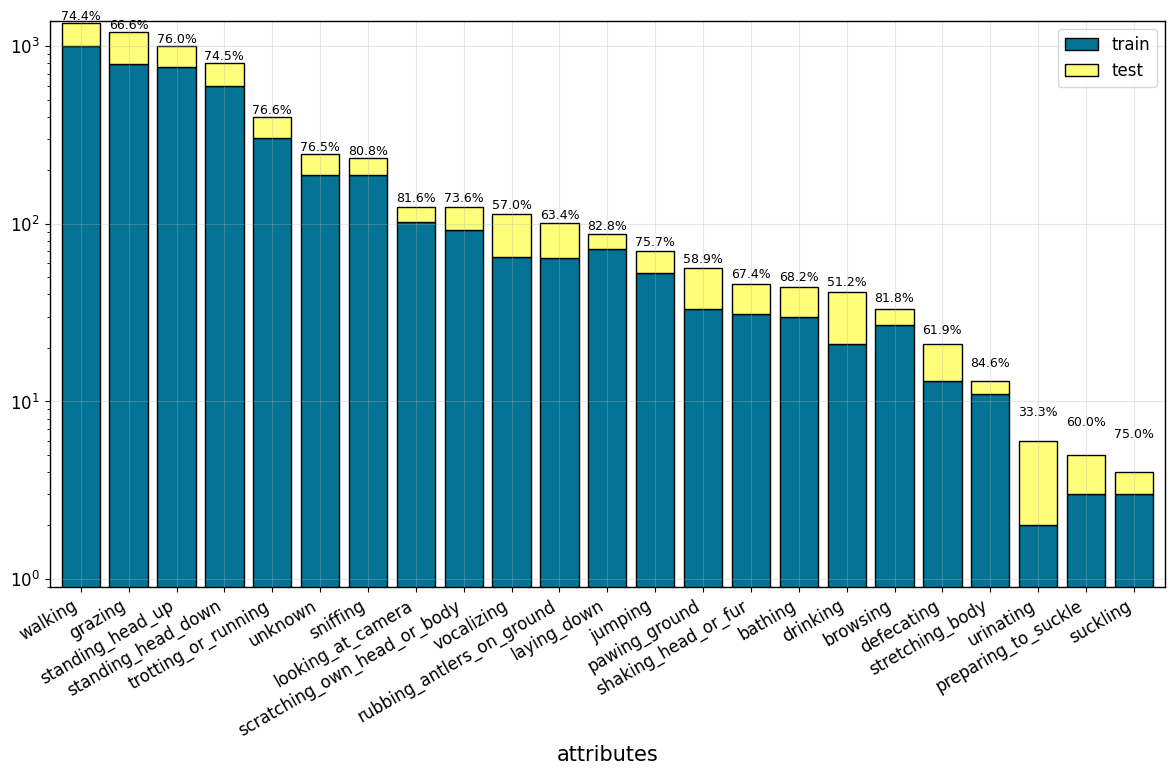

In [41]:
plot_split_frequencies(split_df, ["attributes.action", "attributes.action2"], log=True)

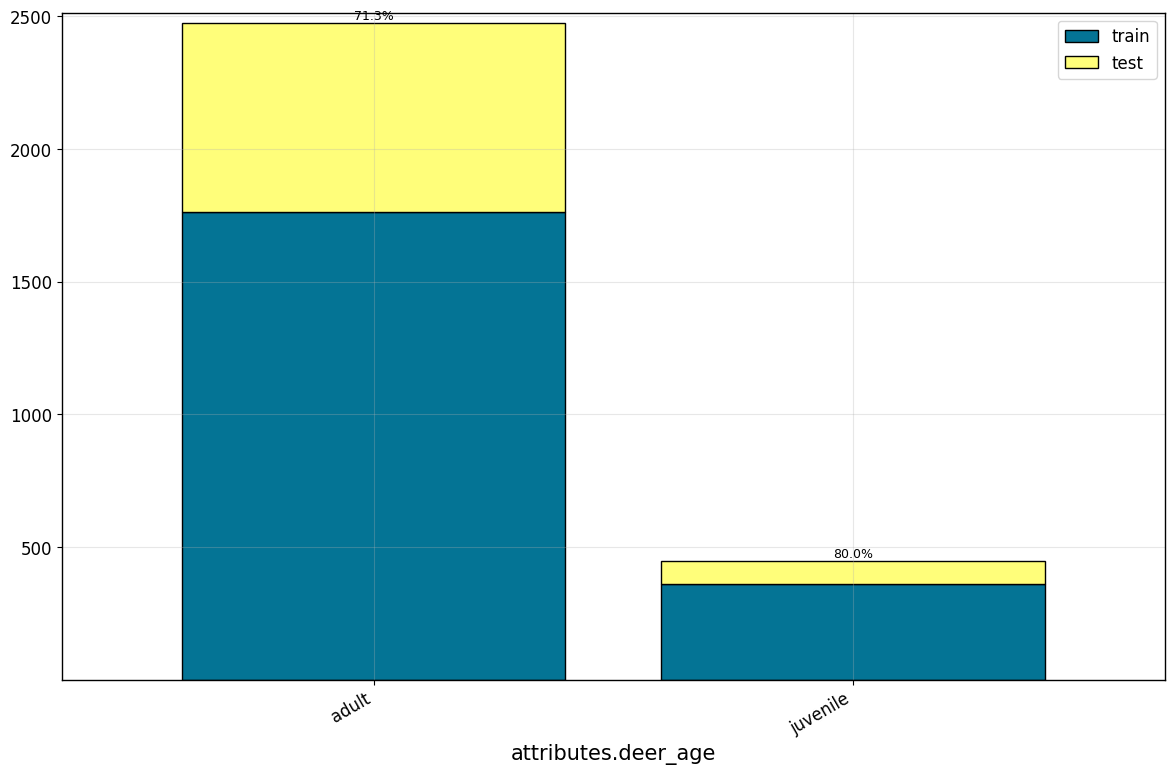

In [42]:
plot_split_frequencies(split_df, "attributes.deer_age")

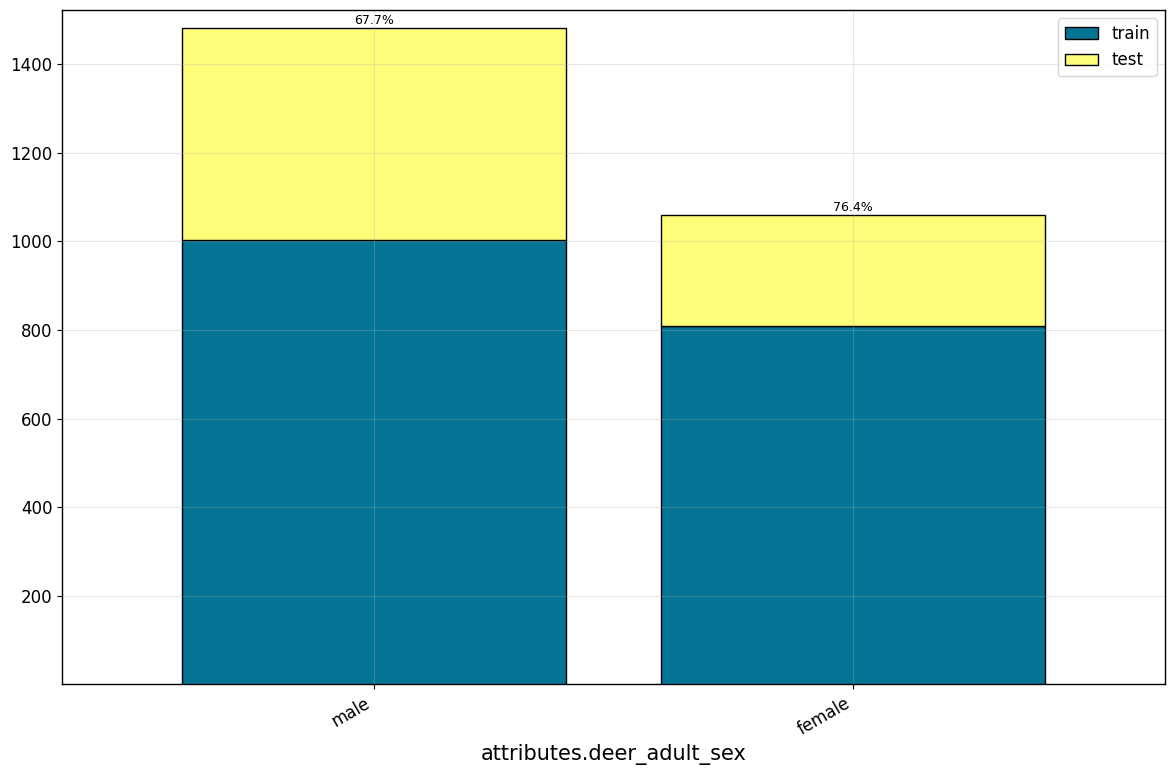

In [43]:
plot_split_frequencies(split_df, "attributes.deer_adult_sex")

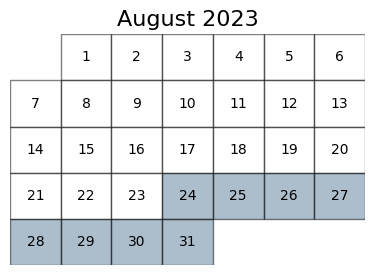

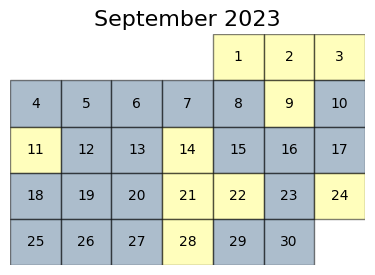

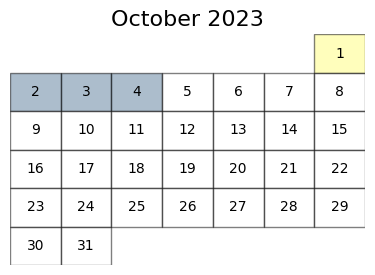

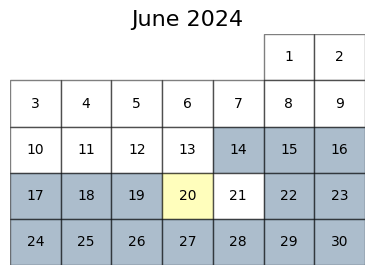

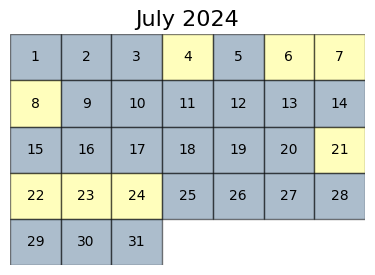

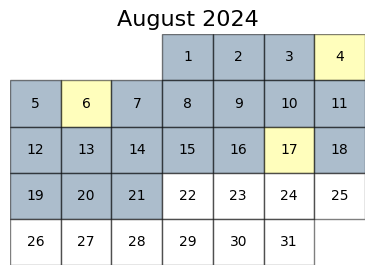

In [24]:
train_days = split_df[split_df["split"]=="train"]["date_time"].dt.date.unique()
test_days = split_df[split_df["split"]=="test"]["date_time"].dt.date.unique()

def plot_calendar(train_days, test_days):
    # Combine all days and determine the range of years and months
    all_days = list(train_days) + list(test_days)
    min_year, max_year = min(day.year for day in all_days), max(day.year for day in all_days)
    min_month, max_month = min(day.month for day in all_days), max(day.month for day in all_days)

    # Iterate over each year and month in the range
    for year in range(min_year, max_year + 1):
        for month in range(1, 13):  # Iterate through all months
            # Filter days for the current year and month
            train_days_month = [day for day in train_days if day.year == year and day.month == month]
            test_days_month = [day for day in test_days if day.year == year and day.month == month]

            # Skip months with no data
            if not train_days_month and not test_days_month:
                continue

            # Create a matrix for the calendar
            cal = calendar.Calendar(firstweekday=0)  # Start with Monday
            month_days = cal.monthdayscalendar(year, month)

            # Create a color map for the days
            day_colors = {}
            for day in train_days_month:
                day_colors[day.day] = "xkcd:steel blue"
            for day in test_days_month:
                day_colors[day.day] = "xkcd:light yellow"

            # Plot the calendar
            fig, ax = plt.subplots(figsize=(4, 3))
            ax.set_xlim(0, 7)
            ax.set_ylim(0, len(month_days))
            ax.axis("off")

            # Add days and color them
            for week_idx, week in enumerate(month_days):
                for day_idx, day in enumerate(week):
                    if day != 0:  # Skip padding days
                        color = day_colors.get(day, "white")  # Default to white if not in train/test
                        ax.add_patch(plt.Rectangle((day_idx, len(month_days) - week_idx - 1), 1, 1, color=color, ec="black", alpha=0.5))
                        ax.text(day_idx + 0.5, len(month_days) - week_idx - 1 + 0.5, str(day), ha="center", va="center", fontsize=10)

            plt.title(f"{calendar.month_name[month]} {year}", fontsize=16)
            plt.tight_layout()
            fig.savefig(f"{calendar.month_name[month]}_{year}"+".svg", transparent=True)
            plt.show()

plot_calendar(train_days, test_days)


### Adding few empty events from both years

In [27]:
#2024 
database_path = Path("/media/EVO870/datasets/SNP_Summer_2024/database.db")

# Get metadata info
conn = sqlite3.connect(database_path)
vid_2024_metadata_df = pd.read_sql("SELECT * FROM Videos", con=conn)
trimmed_metatada_df = pd.read_sql("SELECT file_id, false_positive_video FROM ExperimentData WHERE experiment_name = 'Data_Processing_2024'", con=conn)
fp_videos_df = vid_2024_metadata_df.merge(trimmed_metatada_df, on="file_id")
fp_videos_df["date_time"] = pd.to_datetime(fp_videos_df["date_time"])
conn.close()

In [28]:
# Format to full dataset nomenclature
fp_videos_df["event_id"] = fp_videos_df["event_id"].str.replace("E", "F")
fp_videos_df["file_id"] = fp_videos_df["file_id"].str.replace("E", "F")

# FP events: were previously labeled as such, but also need to not have been picked up in the previous step (should not happen)
tp_events = fp_videos_df[(fp_videos_df["false_positive_video"] != 1) | (fp_videos_df["event_id"].isin(split_df["event_id"].unique()))]["event_id"].unique()

# Diversity > Quantity: we keep only short events
fp_events_df = fp_videos_df[~fp_videos_df["event_id"].isin(tp_events)]
events_duration_df = fp_events_df[["event_id", "duration"]].groupby("event_id").sum()
fp_events_df = fp_events_df[fp_events_df["event_id"].isin(events_duration_df[events_duration_df["duration"]<121].index)]

# Randomly sample among the selected list
train_fp_event_2024 = fp_events_df[fp_events_df["date_time"].dt.date.isin(train_days)].sample(50, random_state=0)
test_fp_event_2024 = fp_events_df[fp_events_df["date_time"].dt.date.isin(test_days)].sample(12, random_state=0)

train_fp_event_2024["split"] = "train"
test_fp_event_2024["split"] = "test"

In [29]:
#2023
videos_2023_df = pd.read_csv("/media/MX500/valentin/datasets/MammAlps/v1/raw_videos_mammalps_v1.csv")
videos_2023_df["date_time"] = pd.to_datetime(videos_2023_df["date_time"])
videos_2023_df.head()

,file_id,site_id,cam_id,video_id,event_id,duration,fps,resolution,date_time,file_path,in_B1,in_B2
0,S1_C1_E103_V0253,S1,C1,V0253,E103,20.5,30.0,1920x1080,2023-09-09 23:22:52,S1/C1/S1_C1_E103_V0253.mp4,True,True
1,S1_C1_E103_V0254,S1,C1,V0254,E103,20.5,30.0,1920x1080,2023-09-09 23:23:16,S1/C1/S1_C1_E103_V0254.mp4,True,True
2,S1_C1_E103_V0255,S1,C1,V0255,E103,11.5,30.0,1920x1080,2023-09-09 23:23:32,S1/C1/S1_C1_E103_V0255.mp4,True,True
3,S1_C1_E103_V0256,S1,C1,V0256,E103,4.0,30.0,1920x1080,2023-09-09 23:23:38,S1/C1/S1_C1_E103_V0256.mp4,True,True
4,S1_C1_E103_V0257,S1,C1,V0257,E103,8.0,30.0,1920x1080,2023-09-09 23:23:54,S1/C1/S1_C1_E103_V0257.mp4,True,True


In [30]:
# For 2023 it was difficult to retrieve the label
# Instead, I use the MammAlps benchmark 2 which already had some preselected false positive events
# Similarly, I make sure that they have not been picked up in the initial steps (should not have happened)
fp_events_2023_df = videos_2023_df[~videos_2023_df["event_id"].isin(split_df["event_id"].unique())]
fp_events_2023_df = fp_events_2023_df[~fp_events_2023_df["in_B1"]]
events_duration_df = fp_events_2023_df[["event_id", "duration"]].groupby("event_id").sum()

# Also keeping shorter events only
fp_events_2023_df = fp_events_2023_df[fp_events_2023_df["event_id"].isin(events_duration_df[events_duration_df["duration"]<121].index)]

# Here there are not enough samples, so we keep everything, not a big deal if it is not balanced across years
train_fp_event_2023 = fp_events_2023_df[fp_events_2023_df["date_time"].dt.date.isin(train_days)].copy()#.sample(100, replace=True, random_state=10)
test_fp_event_2023 = fp_events_2023_df[fp_events_2023_df["date_time"].dt.date.isin(test_days)].copy()#.sample(25, replace=True, random_state=0)

train_fp_event_2023["split"] = "train"
test_fp_event_2023["split"] = "test"

In [31]:
fp_events_df = pd.concat([
    train_fp_event_2023[["file_id", "split", "duration", "fps"]], 
    train_fp_event_2024[["file_id", "split", "duration", "fps"]], 
    test_fp_event_2023[["file_id", "split", "duration", "fps"]], 
    test_fp_event_2024[["file_id", "split", "duration", "fps"]]
])

fp_events_df

,file_id,split,duration,fps
523,S1_C1_E166_V0781,train,120.5,30.0
524,S1_C1_E168_V0783,train,120.5,30.0
605,S1_C1_E218_V0859,train,120.5,30.0
607,S1_C1_E221_V0861,train,120.5,30.0
609,S1_C1_E227_V0864,train,120.5,30.0
...,...,...,...,...
1887,S3_C1_F972_V0541,test,60.5,30.0
19,S1_C1_F144_V0123,test,120.5,30.0
1878,S3_C1_F967_V0532,test,60.5,30.0
844,S1_C3_F177_V0103,test,120.5,30.0


### Creating Metadata file

In [38]:
videos_metadata_df = split_df[["file_id", "trimmed_duration", "fps", "split"]].drop_duplicates("file_id").sort_values("file_id").reset_index(drop=True)
videos_metadata_df["duration"] = videos_metadata_df["trimmed_duration"].round(3)
videos_metadata_df = videos_metadata_df.drop("trimmed_duration", axis=1)
videos_metadata_df = pd.concat([videos_metadata_df, fp_events_df], axis=0).reset_index(drop=True)
videos_metadata_df["video_file_path"] = ""
videos_metadata_df["annotations_file_path"] = ""


videos_metadata_df.sample(5)

,file_id,fps,split,duration,video_file_path,annotations_file_path
1432,S1_C3_F288_V0233,30.0,test,20.833,,
1433,S1_C3_F288_V0234,30.0,test,20.833,,
1868,S2_C2_F516_V0058,30.0,train,2.167,,
2704,S3_C3_E545_V0402,30.0,train,1.333,,
2182,S3_C2_E597_V0117,30.0,train,12.667,,


### Output annotation files to common directory

In [39]:
# Empty events don't necessarily have annotations files. 
# Creating default ones

def create_default_json(duration, fps, file_id: str):
    num_frames = int(duration*fps)
    if "F" in file_id: #2024:
        if ("S1" in file_id) or ("S3" in file_id):
                file_id = file_id.replace("C1", "C4").replace("C2", "C5").replace("C3", "C6")
    site_id, cam_id, event_id, video_id = tuple(file_id.split("_"))

    annotations_dict = {
        "info": {
            "file_id": file_id, 
            "site_id": site_id, 
            "cam_id": cam_id,
            "attributes": {}
        }, 
        "frames": [{"frame_id": i, "detections": []} for i in range(num_frames)]
    }

    return annotations_dict

In [40]:
from pathlib import Path
output_json_folder = Path("/media/EVO870/datasets/prompting-mammalps-v2/annotations/")
output_video_folder = Path("/media/EVO870/datasets/prompting-mammalps-v2/videos/")
input_json_folder_23 = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/SNP_Summer_2023_annotated_tracks_v5/")
input_json_folder_24 = Path("/media/EVO870/datasets/SNP_Summer_2024/experiments/Data_Processing_2024/annotated_tracklets_json/")

input_video_folder_23 = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/SNP_Summer_2023_trimmed_audio")
input_video_folder_24 = Path("/media/EVO870/datasets/SNP_Summer_2024/experiments/Data_Processing_2024/trimmed_videos")

for row in tqdm(videos_metadata_df.drop_duplicates("file_id").itertuples()):
    file_id = row.file_id
    split = row.split
    if "E" in file_id:
        year = 2023
    else:
        year = 2024

    if year == 2023:
        input_video_file = next(input_video_folder_23.rglob(f"*{file_id}*"), None)
        if input_video_file is None:
            print(f"No video found for {file_id}")
            continue
        else:
            output_video_file = output_video_folder / split / input_video_file.relative_to(input_video_folder_23).with_suffix(".mp4")
            output_video_file = Path(str(output_video_file).replace("_trimmed_0.5_30", ""))
            os.makedirs(output_video_file.parent, exist_ok=True)
            #if not output_video_file.exists():
            #    shutil.copy(input_video_file, output_video_file)

        input_json_file = next(input_json_folder_23.rglob(f"*{file_id}*"), None)
        if input_json_file is None:
            print(f"Creating default annotation file for {file_id}")
            default_annotations_dict = create_default_json(row.duration, row.fps, file_id)
            site_id, cam_id, event_id, video_id = tuple(file_id.split("_"))
            output_json_file = Path(output_json_folder / split / site_id / cam_id / file_id).with_suffix(".json")
            os.makedirs(output_json_file.parent, exist_ok=True)
            with open(output_json_file, "w") as f:
                json.dump(default_annotations_dict, f, indent=2)
        else:
            output_json_file = output_json_folder / split / input_json_file.relative_to(input_json_folder_23).with_suffix(".json")
            os.makedirs(output_json_file.parent, exist_ok=True)
            if not output_json_file.exists():
                shutil.copy(input_json_file, output_json_file)
        
    elif year == 2024:
        output_file_id = file_id
        input_file_id = file_id.replace("F", "E")
        if ("S1" in input_file_id) or ("S3" in input_file_id):
            output_file_id = output_file_id.replace("C1", "C4").replace("C2", "C5").replace("C3", "C6")

        input_video_file = next(input_video_folder_24.rglob(f"*{input_file_id}*"), None)
        if input_video_file is None:
            print(f"No video found for {file_id}")
            continue
        else:
            site_id = output_file_id.split("_")[0]
            cam_id = output_file_id.split("_")[1]
            output_video_file = output_video_folder / split / site_id / cam_id / (output_file_id + ".mp4")
            if site_id == "S1" or site_id == "S3":
                output_video_file = Path(str(output_video_file).replace("C1", "C4").replace("C2", "C5").replace("C3", "C6"))
            os.makedirs(output_video_file.parent, exist_ok=True)
            #if not output_video_file.exists():
            #    shutil.copy(input_video_file, output_video_file)
        
        input_json_file = next(input_json_folder_24.rglob(f"*{input_file_id}*"), None)
        if input_json_file is None:
            print(f"Creating default annotation file for {file_id}")
            default_annotations_dict = create_default_json(row.duration, row.fps, file_id)
            site_id, cam_id, event_id, video_id = tuple(file_id.split("_"))
            output_json_file = Path(output_json_folder / split / site_id / cam_id / file_id).with_suffix(".json")
            if site_id == "S1" or site_id == "S3":
                output_json_file = Path(str(output_json_file).replace("C1", "C4").replace("C2", "C5").replace("C3", "C6"))
            os.makedirs(output_json_file.parent, exist_ok=True)
            with open(output_json_file, "w") as f:
                json.dump(default_annotations_dict, f, indent=2)
        else:
            site_id = output_file_id.split("_")[0]
            cam_id = output_file_id.split("_")[1]
            output_json_file = output_json_folder / split / site_id / cam_id / (output_file_id + ".json")
            if site_id == "S1" or site_id == "S3":
                output_json_file = Path(str(output_json_file).replace("C1", "C4").replace("C2", "C5").replace("C3", "C6"))
            os.makedirs(output_json_file.parent, exist_ok=True)
            if not output_json_file.exists():
                shutil.copy(input_json_file, output_json_file)

    # Add file_path in 
    videos_metadata_df.loc[videos_metadata_df["file_id"] == file_id, "video_file_path"] = str(output_video_file.relative_to(output_video_folder))
    videos_metadata_df.loc[videos_metadata_df["file_id"] == file_id, "annotation_file_path"] = str(output_json_file.relative_to(output_json_folder))

0it [00:00, ?it/s]

2764it [00:11, 163.35it/s]

Creating default annotation file for S1_C1_E166_V0781
Creating default annotation file for S1_C1_E168_V0783
Creating default annotation file for S1_C1_E218_V0859
Creating default annotation file for S1_C1_E221_V0861
Creating default annotation file for S1_C1_E227_V0864
Creating default annotation file for S1_C1_E230_V0867
Creating default annotation file for S1_C1_E248_V0877
Creating default annotation file for S1_C1_E75_V0185
Creating default annotation file for S1_C1_E78_V0188
Creating default annotation file for S2_C1_E321_V0067
Creating default annotation file for S3_C2_E413_V0024
Creating default annotation file for S3_C2_E554_V0100
Creating default annotation file for S3_C2_E593_V0114


2781it [00:12, 117.02it/s]

Creating default annotation file for S3_C2_E654_V0147
Creating default annotation file for S3_C2_E703_V0191
Creating default annotation file for S3_C2_E750_V0381
Creating default annotation file for S3_C2_E779_V0466
Creating default annotation file for S3_C2_E801_V0537
Creating default annotation file for S3_C2_E809_V0558
Creating default annotation file for S3_C3_E477_V0235
Creating default annotation file for S3_C3_E484_V0251
Creating default annotation file for S3_C3_E548_V0443
Creating default annotation file for S3_C3_E567_V0473
Creating default annotation file for S3_C3_E568_V0474
Creating default annotation file for S3_C3_E576_V0505
Creating default annotation file for S3_C3_E587_V0537
Creating default annotation file for S3_C3_E604_V0564
Creating default annotation file for S3_C3_E644_V0625
Creating default annotation file for S3_C2_F685_V0114
Creating default annotation file for S3_C1_F841_V0375
Creating default annotation file for S1_C1_F362_V0430


...

Creating default annotation file for S1_C1_F389_V0445
Creating default annotation file for S1_C1_F188_V0143
Creating default annotation file for S1_C1_F416_V0464
Creating default annotation file for S1_C2_F367_V0470
Creating default annotation file for S1_C2_F355_V0468
Creating default annotation file for S3_C2_F661_V0089
Creating default annotation file for S1_C3_F415_V0394
Creating default annotation file for S3_C1_F864_V0472
Creating default annotation file for S3_C2_F934_V0508
Creating default annotation file for S3_C1_F762_V0239
Creating default annotation file for S1_C1_F254_V0247
Creating default annotation file for S1_C1_F391_V0448
Creating default annotation file for S1_C2_F185_V0237
Creating default annotation file for S3_C1_F736_V0195


2847it [00:12, 79.05it/s]

Creating default annotation file for S3_C1_F802_V0321
Creating default annotation file for S1_C1_F42_V0036
Creating default annotation file for S2_C2_E297_V0048
Creating default annotation file for S3_C2_E493_V0078
Creating default annotation file for S3_C2_E500_V0081
Creating default annotation file for S3_C2_E509_V0084
Creating default annotation file for S3_C2_E734_V0343
Creating default annotation file for S3_C3_E504_V0288
Creating default annotation file for S3_C3_E506_V0291
Creating default annotation file for S3_C3_E507_V0292
Creating default annotation file for S3_C3_E508_V0293
Creating default annotation file for S3_C3_E523_V0324
Creating default annotation file for S3_C3_E634_V0611
Creating default annotation file for S1_C3_F298_V0260
Creating default annotation file for S2_C2_F572_V0086
Creating default annotation file for S2_C3_F497_V0072


2865it [00:13, 216.86it/s]

Creating default annotation file for S3_C1_F976_V0547
Creating default annotation file for S3_C1_F981_V0557
Creating default annotation file for S3_C1_F722_V0092
Creating default annotation file for S1_C1_F281_V0298
Creating default annotation file for S3_C1_F972_V0541
Creating default annotation file for S1_C1_F144_V0123
Creating default annotation file for S3_C1_F967_V0532
Creating default annotation file for S1_C3_F177_V0103
Creating default annotation file for S1_C1_F178_V0138


In [41]:
metadata_output_folder = Path("/media/EVO870/datasets/prompting-mammalps-v2/metadata")
for split in ["train", "test"]:
    video_metadata_split_df = videos_metadata_df[videos_metadata_df["split"] == split].reset_index(drop=True)
    video_metadata_split_df = video_metadata_split_df[["video_file_path", "annotation_file_path", "duration", "fps"]]
    video_metadata_split_df.to_csv(metadata_output_folder / (split + ".csv"), index=False)

In [42]:
videos_metadata_df = pd.concat(
    [pd.read_csv("/media/EVO870/datasets/prompting-mammalps-v2/metadata/train.csv"), 
    pd.read_csv("/media/EVO870/datasets/prompting-mammalps-v2/metadata/test.csv")],
    axis=0
)

videos_metadata_df.sample(2)

,video_file_path,annotation_file_path,duration,fps
923,train/S1/C5/S1_C5_F71_V0110.mp4,train/S1/C5/S1_C5_F71_V0110.json,20.833,30.0
1456,train/S2/C3/S2_C3_F483_V0053.mp4,train/S2/C3/S2_C3_F483_V0053.json,11.000,30.0


### Relative coordinates to absolute coordinates for bounding boxes

### Formatting info dict

In [43]:
def from_prop_to_abs_coords(xywh_prop, width, height):
    if isinstance(xywh_prop[0], int): 
        # Has already been converted
        # Happens if the notebook is ran multiple times
        return xywh_prop

    xyxy_coord = [
        xywh_prop[0] * width,
        xywh_prop[1] * height,
        (xywh_prop[0] + xywh_prop[2]) * width,
        (xywh_prop[1] + xywh_prop[3]) * height
    ]
    xyxy_coord = [int(np.round(c)) for c in xyxy_coord]

    return xyxy_coord

def format_info_dict(video_info_dict, file_id):
    # Update Site/Cam ID for 2024
    site_id, cam_id, event_id, video_id = tuple(file_id.split("_"))
    video_info_dict["site_id"] = site_id
    video_info_dict["cam_id"] = cam_id

    # Add file_id
    video_info_dict["file_id"] = file_id
    
    # Remove
    video_info_dict.pop("detection_completion_time", None)
    video_info_dict.pop("format_version", None)
    video_info_dict.pop("detector", None)
    video_info_dict.pop("detector_metadata", None)
    video_info_dict.pop("video_file", None)
    video_info_dict["width"] = video_info_dict.setdefault("width", 1920)
    video_info_dict["height"] = video_info_dict.setdefault("height", 1080)

    return video_info_dict

In [44]:
for annotation_file in tqdm(output_json_folder.rglob("*.json")):
    with open(annotation_file, "r") as f:
        annotations_dict = json.load(f)

    annotations_dict.pop("annotation_category", None) # 2023
    annotations_dict.pop("detection_categories", None) # 2024
    file_id = annotation_file.stem

    video_info_dict = annotations_dict["info"]
    video_info_dict = format_info_dict(video_info_dict, file_id)

    for frame_annotation in annotations_dict["frames"]:
        frame_annotation.pop("max_detection_conf", None)
        updated_detections = []
        for detection in frame_annotation.get("detections", []):
            detection.pop("conf", None)
            detection.pop("category", None)
            detection.pop("occluded", None)
            detection["bbox"] = from_prop_to_abs_coords(detection["bbox"], 1920, 1080)
            if (detection.get("attributes", {})) and detection.get("is_annotated", False):
                # Remove false positive detections
                updated_detections.append(detection)
            detection.pop("is_annotated", None)
        frame_annotation["detections"] = updated_detections
    
    with open(annotation_file, "w") as f:
        json.dump(annotations_dict, f, indent=2)

2865it [01:07, 42.58it/s]


### Prepare label mapping files

In [ ]:
species_list = sorted(split_df["attributes.species"].dropna().unique().tolist())
activities_list =  sorted(split_df["attributes.activity"].dropna().unique().tolist())
actions_list = sorted(list(set(split_df["attributes.action"].dropna().unique().tolist()).union(set(split_df["attributes.action2"].dropna().unique().tolist()))))
deer_age_list = sorted(split_df["attributes.deer_age"].dropna().unique().tolist())
deer_adult_sex_list = sorted(split_df["attributes.deer_adult_sex"].dropna().unique().tolist())

label_mapping = {
    "actions": {v: i for i, v in enumerate(actions_list)},
    "activities": {v: i for i, v in enumerate(activities_list)},
    "deer_ages": {v: i for i, v in enumerate(deer_age_list)},
    "deer_adult_sexes": {v: i for i, v in enumerate(deer_adult_sex_list)},
    "species": {v: i for i, v in enumerate(species_list)},
}

label_mapping_file = metadata_output_folder / "label_mapping.json"
with open(label_mapping_file, "w") as f:
    json.dump(label_mapping, f, indent=2)

label_mapping

{'actions': {'bathing': 0,
  'browsing': 1,
  'defecating': 2,
  'drinking': 3,
  'grazing': 4,
  'jumping': 5,
  'laying_down': 6,
  'looking_at_camera': 7,
  'pawing_ground': 8,
  'preparing_to_suckle': 9,
  'rubbing_antlers_on_ground': 10,
  'scratching_own_head_or_body': 11,
  'shaking_head_or_fur': 12,
  'sniffing': 13,
  'standing_head_down': 14,
  'standing_head_up': 15,
  'stretching_body': 16,
  'suckling': 17,
  'trotting_or_running': 18,
  'unknown': 19,
  'urinating': 20,
  'vocalizing': 21,
  'walking': 22},
 'activities': {'camera_reaction': 0,
  'chasing': 1,
  'courtship': 2,
  'escaping': 3,
  'foraging': 4,
  'grooming': 5,
  'marking_or_wallowing': 6,
  'nursing': 7,
  'playing': 8,
  'resting': 9,
  'unknown': 10,
  'vigilance': 11},
 'deer_ages': {'adult': 0, 'juvenile': 1},
 'deer_adult_sexes': {'female': 0, 'male': 1},
 'species': {'chamois': 0,
  'fox': 1,
  'hare': 2,
  'marten': 3,
  'red_deer': 4,
  'roe_deer': 5,
  'wolf': 6}}

Label mapping for weather was done manually

### Sampling weights based on inverse class frequency
We also add a weight for multiple individuals

In [46]:
output_json_folder = Path("/media/EVO870/datasets/prompting-mammalps-v2/annotations/train")

md_parser = MDVideoOutputParser()
annotated_dict = md_parser.parse_folder(output_json_folder)
annotated_df = md_parser.to_dataframe(file_id_pattern=r"S\d_C\d_[EF]\d+_V\d{4}")
#annotated_df = annotated_df.dropna(subset="segment_id")

annotated_df.sample(2)

  0%|          | 0/2090 [00:00<?, ?it/s]

100%|██████████| 2090/2090 [00:10<00:00, 192.13it/s]


,frame_id,detections,width,height,attributes.Weather,file_id,detection_file_path,track_id,bbox,outside,segment_id,attributes.Social_activity_role,attributes.Action,attributes.Action2,attributes.Activity,attributes.Deer_adult_sex,attributes.Deer_age,attributes.Species
859060,502,"{'track_id': 1, 'bbox': [1006, 564, 1209, 798]...",NaN,NaN,clear,S1_C4_F204_V0171,S1/C4/S1_C4_F204_V0171.json,1.0,"[1006, 564, 1209, 798]",False,1.0,n/a,grazing,none,foraging,NaN,juvenile,red_deer
1442551,1116,"{'track_id': 1, 'bbox': [1517, 841, 1544, 863]...",NaN,NaN,sunny,S2_C1_F602_V0109,S2/C1/S2_C1_F602_V0109.json,1.0,"[1517, 841, 1544, 863]",False,2.0,n/a,walking,none,foraging,male,adult,roe_deer


In [47]:
count_per_attr_df = pd.DataFrame(index=None)
for attr in ["attributes.Weather", "attributes.Action", "attributes.Action2", "attributes.Activity", "attributes.Species", "attributes.Deer_age", "attributes.Deer_adult_sex"]:
    count_per_attr = annotated_df[["file_id", "frame_id", attr]].drop_duplicates()[["frame_id", attr]].groupby(attr).count()
    count_per_attr["total"] = count_per_attr["frame_id"].sum()
    count_per_attr_df = pd.concat([count_per_attr_df, count_per_attr])

count_per_attr_df = count_per_attr_df.drop("none", axis=0)
count_per_attr_df = count_per_attr_df.reset_index(drop=False).groupby("index").agg({"frame_id": "sum", "total": "max"})
count_per_attr_df["freq"] = count_per_attr_df["frame_id"] / count_per_attr_df["total"]
count_per_attr_df = count_per_attr_df[["freq"]]
count_per_attr_dict = count_per_attr_df["freq"].to_dict()

In [48]:
sample_weights = {}
for file_id in tqdm(annotated_df["file_id"].unique()):
    file_df = annotated_df[annotated_df["file_id"] == file_id]
    count_per_attr_file_df = pd.DataFrame(index=None)
    for attr in ["attributes.Weather", "attributes.Action", "attributes.Action2", "attributes.Activity", "attributes.Species", "attributes.Deer_age", "attributes.Deer_adult_sex"]:
        count_per_attr = file_df[["file_id", "frame_id", attr]].drop_duplicates()[["frame_id", attr]].groupby(attr).count()
        count_per_attr["total"] = count_per_attr["frame_id"].sum()
        count_per_attr_file_df = pd.concat([count_per_attr_file_df, count_per_attr])
    count_per_attr_file_df = count_per_attr_file_df.drop("none", axis=0, errors="ignore")
    count_per_attr_file_df = count_per_attr_file_df.reset_index(drop=False).rename(columns={"index": "attribute"})
    count_per_attr_file_df["weight"] = count_per_attr_file_df["attribute"].map(count_per_attr_dict)
    sample_weight = count_per_attr_file_df["weight"].mean()
    nb_tracks = file_df["track_id"].max()
    if nb_tracks > 1:
        sample_weight /= 3
    sample_weights[file_id] = sample_weight

100%|██████████| 2090/2090 [03:04<00:00, 11.33it/s]


In [49]:
sample_weights_df = pd.DataFrame.from_dict(sample_weights, orient="index", columns=["sampling_weight"]).reset_index(drop=False).rename(columns={"index":"file_id"}).sort_values("sampling_weight")
sample_weights_df["sampling_weight"] = 1.0 / (sample_weights_df["sampling_weight"] - sample_weights_df["sampling_weight"].min() + 0.1)
sample_weights_df["sampling_weight"].describe()

count    2090.000000
mean        2.649941
std         1.501645
min         1.556529
25%         1.654834
50%         2.045303
75%         2.787854
max        10.000000
Name: sampling_weight, dtype: float64

In [50]:
sample_weights_df.sort_values("sampling_weight")

,file_id,sampling_weight
1509,S1_C2_E122_V0212,1.556529
1505,S1_C2_E94_V0106,1.556529
1489,S1_C2_E105_V0125,1.556529
1487,S1_C2_E105_V0140,1.556529
1569,S1_C2_E94_V0104,1.556529
...,...,...
116,S3_C3_E642_V0619,8.605548
318,S3_C2_E642_V0146,8.825545
1723,S1_C2_E29_V0040,9.191006
367,S3_C2_E710_V0245,9.693110


In [51]:
videos_metadata_df["file_id"] = videos_metadata_df["video_file_path"].apply(lambda d: Path(d).stem)
videos_metadata_df["sampling_weight"] = 1.0 / videos_metadata_df["file_id"].map(sample_weights, "ignore").fillna(1.0)
videos_metadata_df

,video_file_path,annotation_file_path,duration,fps,file_id,sampling_weight
0,train/S1/C1/S1_C1_E104_V0262.mp4,train/S1/C1/S1_C1_E104_V0262.json,20.333,30.0,S1_C1_E104_V0262,1.671748
1,train/S1/C1/S1_C1_E104_V0263.mp4,train/S1/C1/S1_C1_E104_V0263.json,11.000,30.0,S1_C1_E104_V0263,1.671748
2,train/S1/C1/S1_C1_E104_V0264.mp4,train/S1/C1/S1_C1_E104_V0264.json,5.833,30.0,S1_C1_E104_V0264,1.671748
3,train/S1/C1/S1_C1_E104_V0265.mp4,train/S1/C1/S1_C1_E104_V0265.json,1.333,30.0,S1_C1_E104_V0265,1.671748
4,train/S1/C1/S1_C1_E104_V0266.mp4,train/S1/C1/S1_C1_E104_V0266.json,2.833,30.0,S1_C1_E104_V0266,1.671748
...,...,...,...,...,...,...
770,test/S3/C4/S3_C4_F972_V0541.mp4,test/S3/C4/S3_C4_F972_V0541.json,60.500,30.0,S3_C4_F972_V0541,1.000000
771,test/S1/C4/S1_C4_F144_V0123.mp4,test/S1/C4/S1_C4_F144_V0123.json,120.500,30.0,S1_C4_F144_V0123,1.000000
772,test/S3/C4/S3_C4_F967_V0532.mp4,test/S3/C4/S3_C4_F967_V0532.json,60.500,30.0,S3_C4_F967_V0532,1.000000
773,test/S1/C6/S1_C6_F177_V0103.mp4,test/S1/C6/S1_C6_F177_V0103.json,120.500,30.0,S1_C6_F177_V0103,1.000000


In [52]:
videos_metadata_df[videos_metadata_df["video_file_path"].str.contains("train")]["sampling_weight"].describe()

count    2090.000000
mean        3.174438
std         2.299452
min         1.671748
25%         1.785678
50%         2.248979
75%         3.180461
max        17.946544
Name: sampling_weight, dtype: float64

In [53]:
metadata_output_folder = Path("/media/EVO870/datasets/prompting-mammalps-v2/metadata")
for split in ["train", "test"]:
    video_metadata_split_df = videos_metadata_df[videos_metadata_df["video_file_path"].str.contains(split)].reset_index(drop=True)
    video_metadata_split_df = video_metadata_split_df[["video_file_path", "annotation_file_path", "duration", "fps", "sampling_weight"]]
    video_metadata_split_df.to_csv(metadata_output_folder / (split + ".csv"), index=False)

In [54]:
sample_weights_df["sampling_weight"].describe()

count    2090.000000
mean        2.649941
std         1.501645
min         1.556529
25%         1.654834
50%         2.045303
75%         2.787854
max        10.000000
Name: sampling_weight, dtype: float64

In [55]:
videos_metadata_df.sort_values("sampling_weight")

,video_file_path,annotation_file_path,duration,fps,file_id,sampling_weight
764,test/S2/C2/S2_C2_F572_V0086.mp4,test/S2/C2/S2_C2_F572_V0086.json,120.500,30.0,S2_C2_F572_V0086,1.000000
765,test/S2/C3/S2_C3_F497_V0072.mp4,test/S2/C3/S2_C3_F497_V0072.json,120.500,30.0,S2_C3_F497_V0072,1.000000
766,test/S3/C4/S3_C4_F976_V0547.mp4,test/S3/C4/S3_C4_F976_V0547.json,60.500,30.0,S3_C4_F976_V0547,1.000000
767,test/S3/C4/S3_C4_F981_V0557.mp4,test/S3/C4/S3_C4_F981_V0557.json,60.500,30.0,S3_C4_F981_V0557,1.000000
768,test/S3/C4/S3_C4_F722_V0092.mp4,test/S3/C4/S3_C4_F722_V0092.json,60.500,30.0,S3_C4_F722_V0092,1.000000
...,...,...,...,...,...,...
2005,train/S3/C3/S3_C3_E642_V0619.mp4,train/S3/C3/S3_C3_E642_V0619.json,60.333,30.0,S3_C3_E642_V0619,13.903343
1605,train/S3/C2/S3_C2_E642_V0146.mp4,train/S3/C2/S3_C2_E642_V0146.json,59.000,30.0,S3_C2_E642_V0146,14.486772
699,train/S1/C2/S1_C2_E29_V0040.mp4,train/S1/C2/S1_C2_E29_V0040.json,47.833,30.0,S1_C2_E29_V0040,15.498336
1676,train/S3/C2/S3_C2_E710_V0245.mp4,train/S3/C2/S3_C2_E710_V0245.json,60.167,30.0,S3_C2_E710_V0245,16.981649


## Meteo

In [ ]:
total_csv = pd.concat(
    [pd.read_csv("/media/EVO870/datasets/prompting-mammalps-v2/metadata/train.csv"), 
    pd.read_csv("/media/EVO870/datasets/prompting-mammalps-v2/metadata/test.csv")],
    axis=0
)

total_csv["event_id"] = total_csv["video_file_path"].apply(lambda d: d.split(r"/")[3].split("_")[2])
events_2024 = total_csv[total_csv["event_id"].str.contains("F")]["event_id"].str.replace("F", "E").unique()

In [ ]:
events_annotations = pd.read_csv("/media/EVO870/datasets/SNP_Summer_2024/experiments/Data_Processing_2024/events_annotations.csv")
annotated_events = events_annotations[events_annotations["checked"] == "TRUE"]["event_id"].unique()

In [ ]:
remaining_events_to_annotate = set(events_2024) - set(annotated_events)

print(sorted(remaining_events_to_annotate))
print(len(remaining_events_to_annotate))

[]
0


In [ ]:
print(sorted(events_annotations[events_annotations["checked"] == "TRUE"]["meteo"].unique()))

['clear_dawn', 'clear_evening', 'clear_evening_windy', 'clear_morning', 'clear_morning_windy', 'clear_night', 'clear_night_windy', 'clear_windy', 'clear_windy_evening', 'clear_windy_night', 'cloudy', 'cloudy_evening', 'cloudy_windy', 'foggy_night', 'overcast', 'overcast_evening', 'overcast_night', 'overcast_windy', 'rainy', 'rainy_morning', 'rainy_night', 'rainy_windy_night', 'sunny', 'sunny_windy', 'windy', 'windy_clear_morning', 'windy_cloudy', 'windy_night', 'windy_rainy_night']


In [ ]:
mapping = {
    'sunny_windy': "sunny", 
    'clear_evening': "clear", 
    'clear_morning': "clear", 
    'clear_windy': "clear",
    'sunny': "sunny",
    'clear_night': "clear", 
    'overcast': "overcast", 
    'clear_morning_windy': "clear", 
    'windy': "clear",
    'cloudy': "overcast", 
    'cloudy_windy': "overcast", 
    'rainy': "rainy", 
    'overcast_windy': "overcast", 
    'clear_dawn': "clear",
    'clear_evening_windy': "clear", 
    'overcast_evening': "overcast", 
    'clear_night_windy': "clear",
    'overcast_night': "overcast", 
    'rainy_night': "rainy", 
    'clear_windy_evening': "clear",
    'foggy_night': "overcast", 
    'windy_night': "clear", 
    'windy_rainy_night': "rainy",
    'rainy_windy_night': "rainy",
    'clear_windy_night': "clear",
    'rainy_morning': "rainy", 
    'windy_cloudy': "overcast",
    'windy_clear_morning': "clear",
    'cloudy_evening': "overcast" 
}

In [ ]:
events_annotations_2023 = pd.read_csv("/media/MX500/valentin/datasets/SNP_Summer_2023/annotation/events_annotation_df.csv")
events_annotations_2023

,raw_file_path,event_id,site_cam_id,file_id,species_1,individuals_1,species_2,individuals_2,env. cond,Unnamed: 9
0,Site1/CAM001/100_BTCF/IMG_0031.MP4,E10,S1_C1,S1_C1_E10_V0031,roe_deer,3.0,NaN,NaN,cloudy,NaN
1,Site1/CAM001/100_BTCF/IMG_0251.MP4,E100,S1_C1,S1_C1_E100_V0251,chamois,2.0,NaN,NaN,foggy,NaN
2,Site1/CAM003/100_BTCF/IMG_0044.MP4,E102,S1_C3,S1_C3_E102_V0044,red_deer,1.0,NaN,NaN,clear_night,NaN
3,Site1/CAM001/100_BTCF/IMG_0253.MP4,E103,S1_C1,S1_C1_E103_V0253,red_deer,1.0,NaN,NaN,clear_night,NaN
4,Site1/CAM001/100_BTCF/IMG_0254.MP4,E103,S1_C1,S1_C1_E103_V0254,red_deer,1.0,NaN,NaN,clear_night,NaN
...,...,...,...,...,...,...,...,...,...,...
1935,Site1/CAM001/100_BTCF/IMG_0250.MP4,E99,S1_C1,S1_C1_E99_V0250,red_deer,2.0,NaN,NaN,foggy_night,NaN
1936,Site1/CAM002/100_BTCF/IMG_0114.MP4,E99,S1_C2,S1_C2_E99_V0114,red_deer,2.0,NaN,NaN,foggy_night,NaN
1937,Site1/CAM002/100_BTCF/IMG_0115.MP4,E99,S1_C2,S1_C2_E99_V0115,red_deer,2.0,NaN,NaN,foggy_night,NaN
1938,Site1/CAM002/100_BTCF/IMG_0116.MP4,E99,S1_C2,S1_C2_E99_V0116,red_deer,2.0,NaN,NaN,foggy_night,NaN


In [ ]:
# Adding weather attribute to fp files
from pathlib import Path
import json
for annotation_file in Path("/media/EVO870/datasets/prompting-mammalps-v2/annotations").rglob("*.json"):
    with open(annotation_file, "r") as f:
        annotation_dict = json.load(f)
        info_dict = annotation_dict["info"]
    
    if "weather" not in info_dict["attributes"]:
        event_id = info_dict["file_id"].split("_")[2]
        if "F" in event_id:
            weather = events_annotations[events_annotations["event_id"] == event_id.replace("F", "E")]["meteo"].values[0]
            info_dict["attributes"]["weather"] = mapping[weather]
            annotation_dict["info"] = info_dict
            with open(annotation_file, "w") as f:
                json.dump(annotation_dict, f, indent=2)
        else:
            weather = events_annotations_2023[events_annotations_2023["event_id"] == event_id]["env. cond"].values[0]
            info_dict["attributes"]["weather"] = mapping[weather]
            annotation_dict["info"] = info_dict
            with open(annotation_file, "w") as f:
                json.dump(annotation_dict, f, indent=2)
